---
title: "Multimodal plots"
format: html
---

In [2]:
import sys
sys.path.insert(0, "..")

import importlib.util
_spec = importlib.util.spec_from_file_location("mock_data", "00_mock_data.py")
_m = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_m)

## `plot_bimodal_scatter` — RNA vs protein

/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/max-nuber/miniforge3/envs/celltypist_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


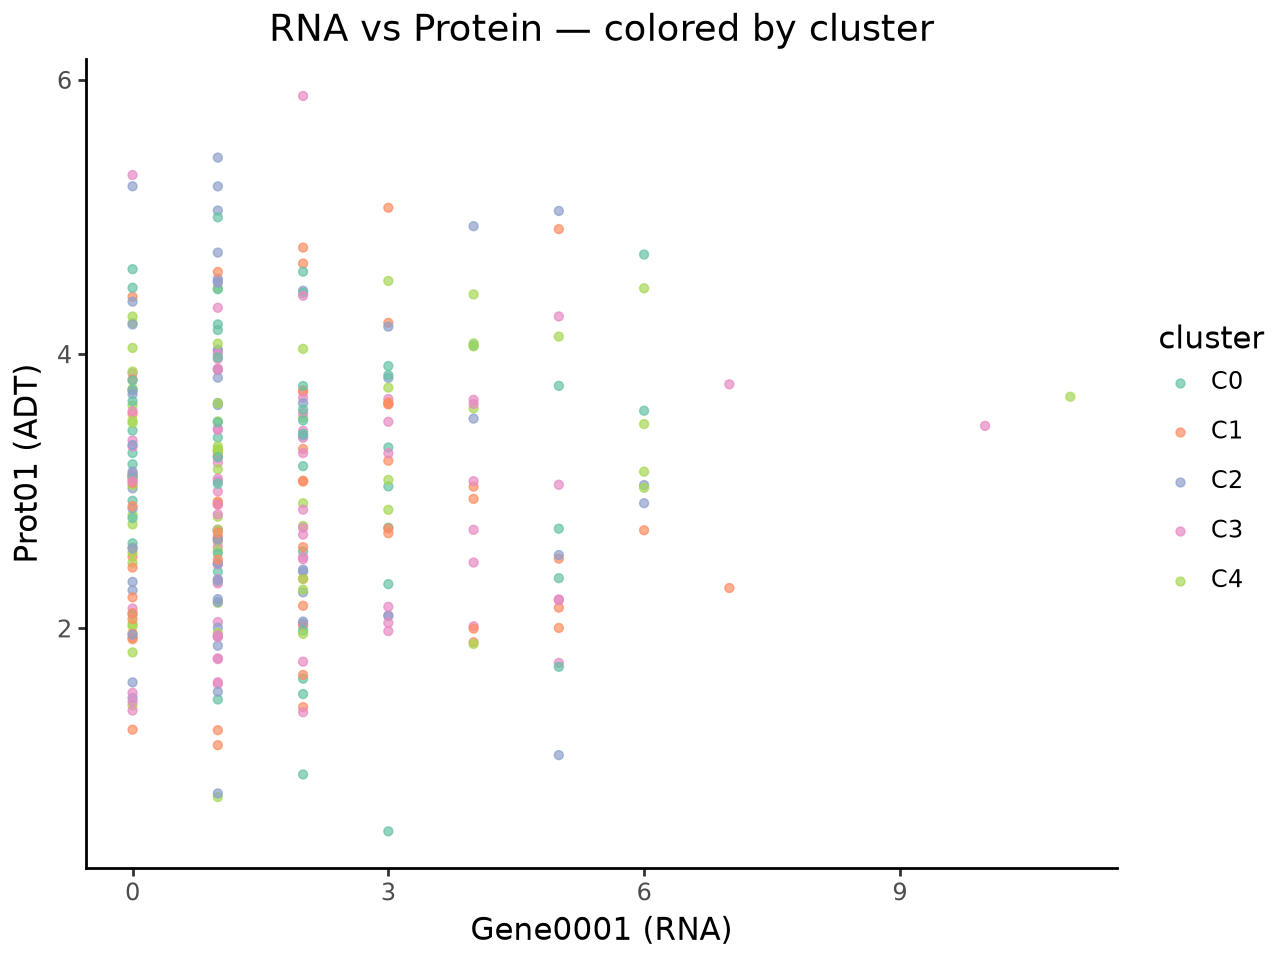

In [3]:
try:
    mdata = _m.make_mock_mudata(n_cells=300, n_rna=50, n_prot=10, seed=42)
    from ggnomics import plot_bimodal_scatter

    p = plot_bimodal_scatter(
        mdata, x_feature="Gene0001", y_feature="Prot01",
        x_mod="rna", y_mod="prot", color="cluster",
        title="RNA vs Protein — colored by cluster",
        x_label="Gene0001 (RNA)", y_label="Prot01 (ADT)",
    )
    p.show()
except ImportError as e:
    print(f"Skipped (mudata not installed): {e}")

### With marginal distributions

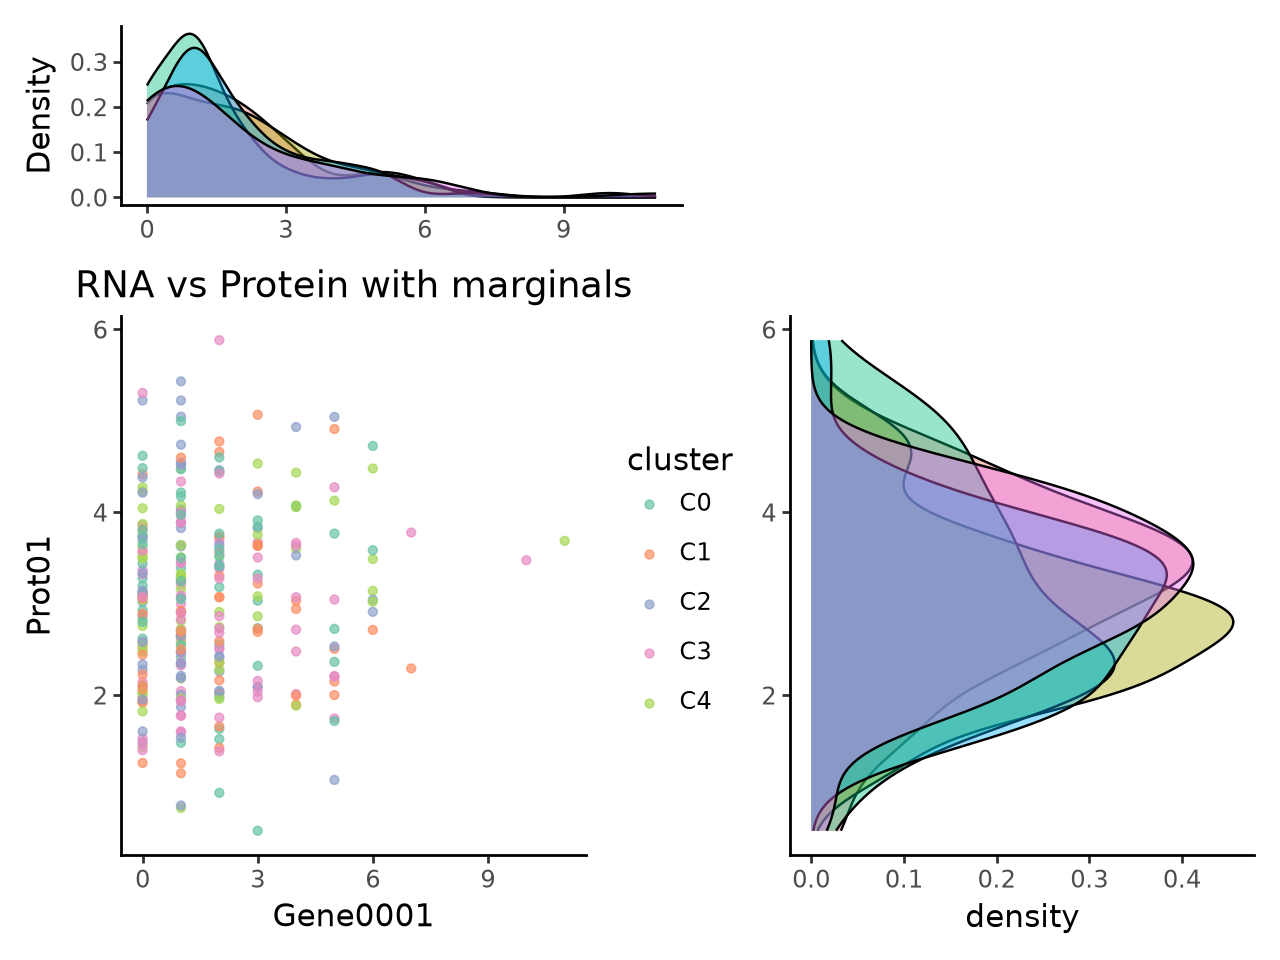

In [4]:
try:
    bricks = plot_bimodal_scatter(
        mdata, x_feature="Gene0001", y_feature="Prot01",
        x_mod="rna", y_mod="prot", color="cluster",
        add_marginal=True,
        title="RNA vs Protein with marginals",
    )
    bricks.show()
except ImportError as e:
    print(f"Skipped (mudata not installed): {e}")

## `plot_adt_qc` — isotype control overlay

### Without grouping

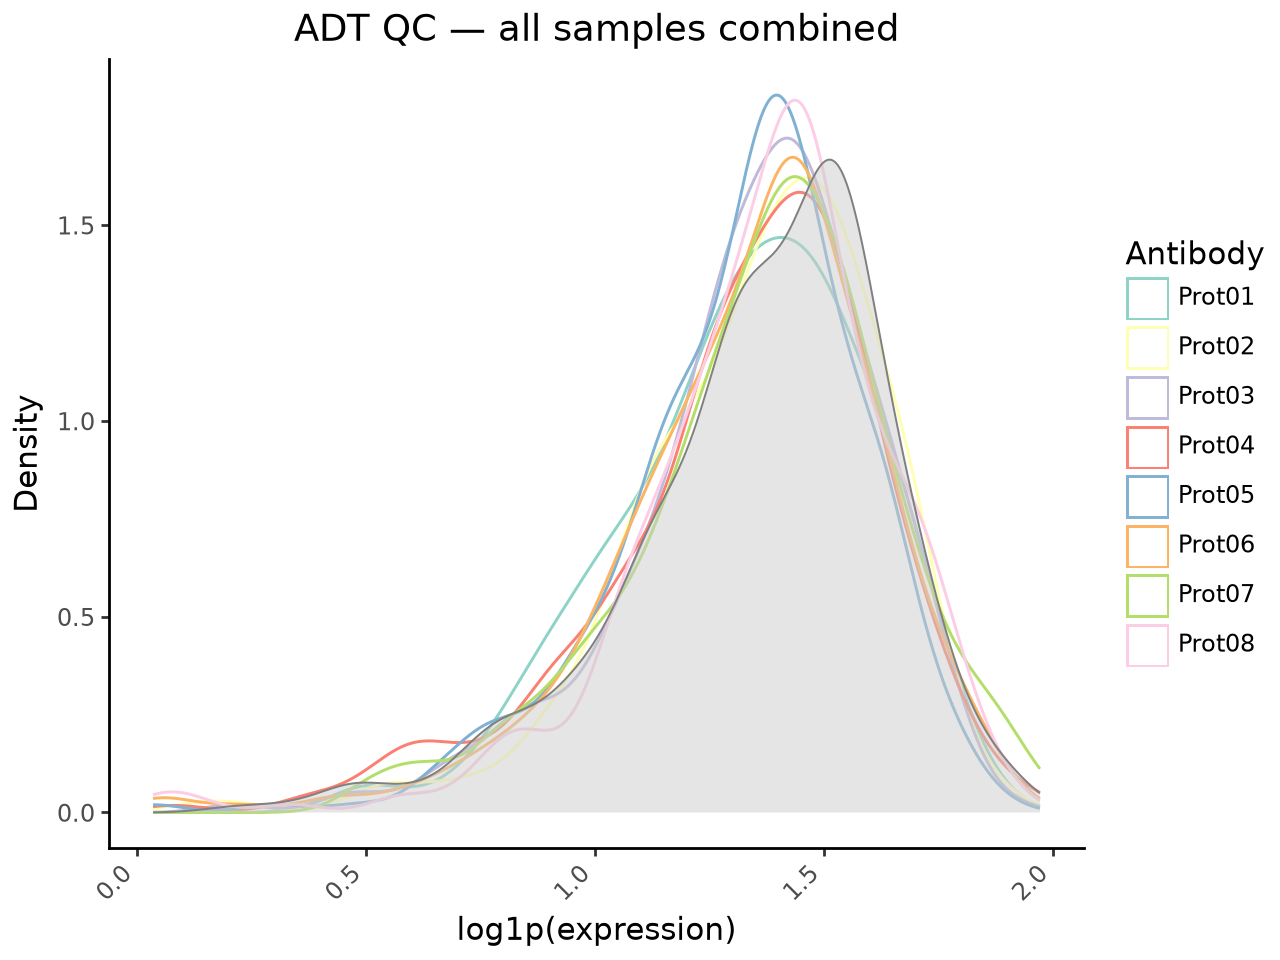

In [7]:
try:
    import anndata, numpy as np
    rng = np.random.default_rng(42)
    n = 300
    prot_names = [f"Prot{i+1:02d}" for i in range(8)] + ["IgG1", "IgG2a"]
    X = np.abs(rng.normal(3, 1, (n, len(prot_names)))).astype(np.float32)
    adata_prot = anndata.AnnData(X=X)
    adata_prot.var_names = prot_names
    adata_prot.obs["sample"] = np.where(rng.random(n) < 0.5, "S1", "S2")

    from ggnomics import plot_adt_qc
    p_adt = plot_adt_qc(adata_prot, isotype_controls=["IgG1", "IgG2a"],
                         log1p=True, title="ADT QC — all samples combined")
    p_adt.show()
except Exception as e:
    print(f"Error: {e}")

### Faceted by sample

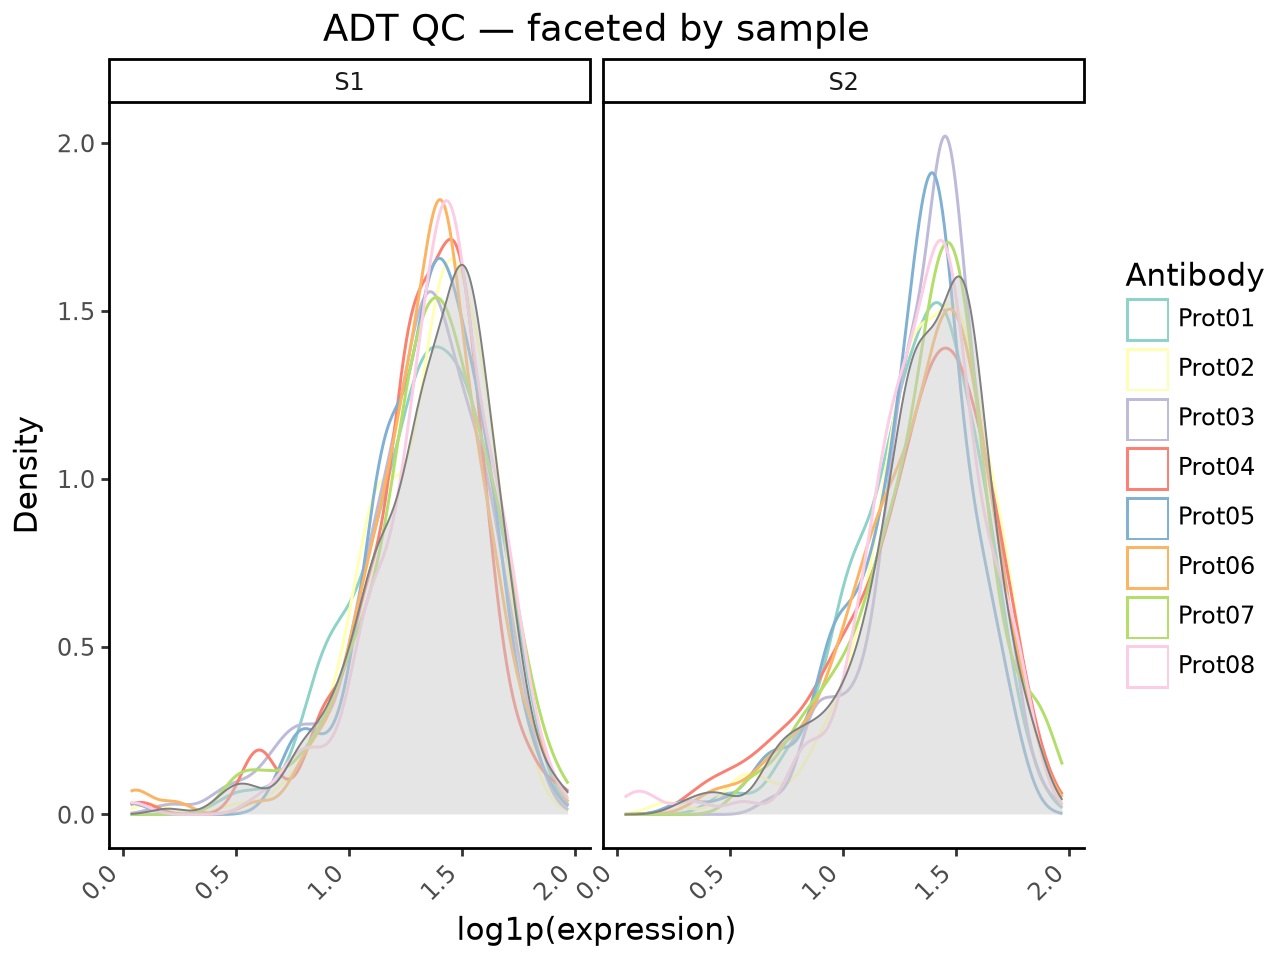

In [8]:
try:
    p_facet = plot_adt_qc(adata_prot, isotype_controls=["IgG1", "IgG2a"],
                           group_by="sample", log1p=True,
                           title="ADT QC — faceted by sample")
    p_facet.show()
except Exception as e:
    print(f"Error: {e}")

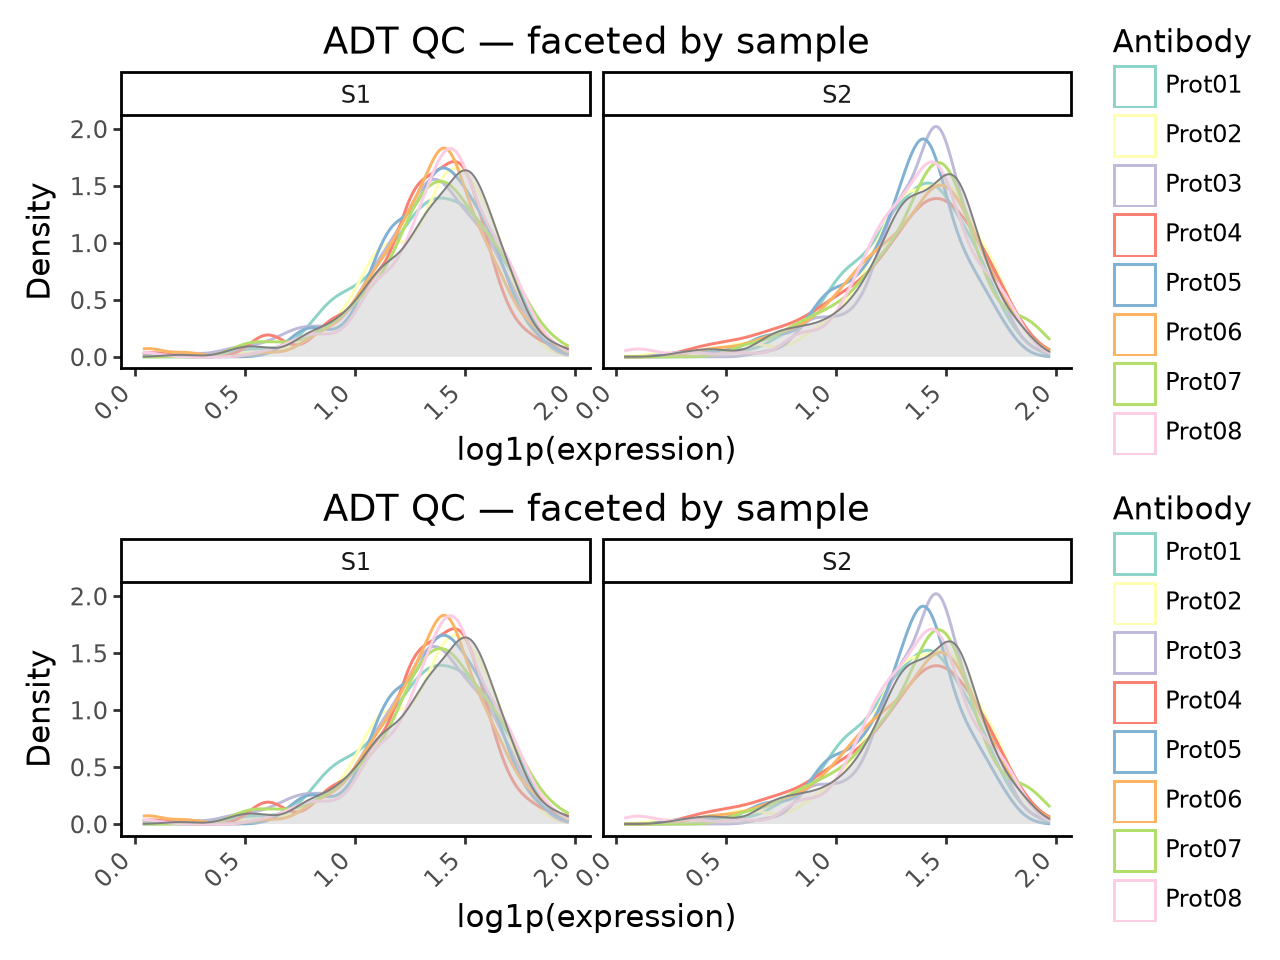

In [11]:
p_facet / p_facet